<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
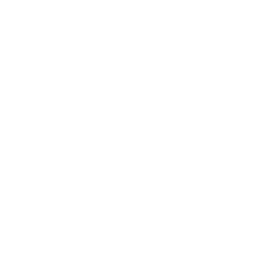
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Εισαγωγή Αποτελεσμάτων Κεντρικού Κλινικού Εργαστηρίου</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Φαρμακευτική / Βιοστατιστική &nbsp;|&nbsp; Μάρτιος 2026</p>
</div>
</div>
</div>

## Περίληψη

Εισαγωγή ενός αρχείου CSV κεντρικού εργαστηρίου που περιέχει πίνακες κλινικής χημείας και αιματολογίας για μια ογκολογική δοκιμή Φάσης II. Χρησιμοποιήστε GUESSINGROWS=MAX ώστε οι τύποι των μεταβλητών να συναχθούν σωστά σε όλο το σύνολο δεδομένων, αποτρέποντας την εσφαλμένη ταξινόμηση αραιών αριθμητικών πεδίων ως χαρακτήρων. Τροφοδοτήστε το εισαγόμενο σύνολο δεδομένων στην PROC MEANS με ODS OUTPUT για να παραχθούν συνοπτικά στατιστικά εύρους αναφοράς κατά αναλύτη και επίσκεψη, υποστηρίζοντας την ανασκόπηση των εργαστηριακών φυσιολογικών τιμών από τον ιατρικό επόπτη.

## Πηγές Δεδομένων

| Πηγή | Περιγραφή | Εγγραφές |
|--------|-------------|--------|
| central_lab_results.csv | Εξαγωγή CSV κεντρικού εργαστηρίου με πίνακες χημείας και αιματολογίας | ~5.000 |
| WORK.LAB_IMPORT | Εισαγόμενο σύνολο δεδομένων SAS από την PROC IMPORT | ~5.000 |

---

In [1]:
/* --------------------------------------------------------
   Δημιουργία συνθετικού αρχείου CSV κεντρικού εργαστηρίου
   Στήλες: USUBJID, VISIT, LBTESTCD, LBTEST, LBCAT,
            LBORRES, LBORRESU, LBORNRLO, LBORNRHI,
            LBSTRESN, LBSTRESC, LBBLFL, LBDTC
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.lab_csv_source;
    CALL streaminit(42);
    LENGTH usubjid $16 visit $40 lbtestcd $8 lbtest $60
           lbcat $30 lborres $12 lborresu $10
           lbornrlo $8 lbornrhi $8 lbstresc $12
           lbblfl $1 lbdtc $10;
    ARRAY test_codes[8] $8 _temporary_
        ('ALT' 'AST' 'BILI' 'CREAT' 'ALB' 'HGB' 'WBC' 'PLT');
    ARRAY test_units[8] $10 _temporary_
        ('U/L' 'U/L' 'mg/dL' 'mg/dL' 'g/dL' 'g/dL' '10^3/uL' '10^3/uL');
    ARRAY lo_norm[8] _temporary_ (7 8 0.1 0.6 3.5 12.0 4.0 150);
    ARRAY hi_norm[8] _temporary_ (56 40 1.2 1.2 5.5 17.5 11.0 400);
    ΕΠΑΝΑΛΗΨΗ subj = 1 ΕΩΣ 125;
        usubjid = cat('ONC-2026-', PUT(subj, z4.));
        ΕΠΑΝΑΛΗΨΗ v = 1 ΕΩΣ 5;
            /* Ονόματα επισκέψεων γραμμένα ως άμεση ανάθεση IF/ELSE
               (όχι πίνακας _temporary_) ώστε να αποφευχθεί το γνωστό
               σφάλμα περικοπής μη-ASCII τιμών σε array look-up */
            ΕΑΝ v = 1 ΤΟΤΕ visit = "ΔΙΑΛΟΓΗ";
            ΑΛΛΙΩΣ ΕΑΝ v = 2 ΤΟΤΕ visit = "ΚΥΚΛΟΣ 1 ΗΜΕΡΑ 1";
            ΑΛΛΙΩΣ ΕΑΝ v = 3 ΤΟΤΕ visit = "ΚΥΚΛΟΣ 2 ΗΜΕΡΑ 1";
            ΑΛΛΙΩΣ ΕΑΝ v = 4 ΤΟΤΕ visit = "ΚΥΚΛΟΣ 3 ΗΜΕΡΑ 1";
            ΑΛΛΙΩΣ visit = "ΤΕΛΟΣ ΘΕΡΑΠΕΙΑΣ";
            ΕΠΑΝΑΛΗΨΗ t = 1 ΕΩΣ 8;
                lbtestcd = test_codes[t];
                /* Ονόματα εξετάσεων και κατηγορίες γραμμένα ως IF/ELSE
                   για τον ίδιο λόγο (μη-ASCII, όχι array look-up) */
                ΕΑΝ t = 1 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ; lbtest = "Αλανινική Αμινοτρανσφεράση"; lbcat = "ΧΗΜΕΙΑ"; ΤΕΛΟΣ;
                ΑΛΛΙΩΣ ΕΑΝ t = 2 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ; lbtest = "Ασπαρτική Αμινοτρανσφεράση"; lbcat = "ΧΗΜΕΙΑ"; ΤΕΛΟΣ;
                ΑΛΛΙΩΣ ΕΑΝ t = 3 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ; lbtest = "Χολερυθρίνη"; lbcat = "ΧΗΜΕΙΑ"; ΤΕΛΟΣ;
                ΑΛΛΙΩΣ ΕΑΝ t = 4 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ; lbtest = "Κρεατινίνη"; lbcat = "ΧΗΜΕΙΑ"; ΤΕΛΟΣ;
                ΑΛΛΙΩΣ ΕΑΝ t = 5 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ; lbtest = "Λευκωματίνη"; lbcat = "ΧΗΜΕΙΑ"; ΤΕΛΟΣ;
                ΑΛΛΙΩΣ ΕΑΝ t = 6 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ; lbtest = "Αιμοσφαιρίνη"; lbcat = "ΑΙΜΑΤΟΛΟΓΙΑ"; ΤΕΛΟΣ;
                ΑΛΛΙΩΣ ΕΑΝ t = 7 ΤΟΤΕ ΕΠΑΝΑΛΗΨΗ; lbtest = "Λευκά Αιμοσφαίρια"; lbcat = "ΑΙΜΑΤΟΛΟΓΙΑ"; ΤΕΛΟΣ;
                ΑΛΛΙΩΣ ΕΠΑΝΑΛΗΨΗ; lbtest = "Αιμοπετάλια"; lbcat = "ΑΙΜΑΤΟΛΟΓΙΑ"; ΤΕΛΟΣ;
                lborresu = test_units[t];
                mid = (lo_norm[t] + hi_norm[t]) / 2;
                spread = (hi_norm[t] - lo_norm[t]) / 4;
                lbstresn = round(rand('normal', mid, spread), 0.01);
                ΕΑΝ lbstresn < 0 ΤΟΤΕ lbstresn = 0.01;
                lborres = PUT(lbstresn, 8.2);
                lbstresc = lborres;
                lbornrlo = PUT(lo_norm[t], 8.2);
                lbornrhi = PUT(hi_norm[t], 8.2);
                ΕΑΝ v = 1 ΤΟΤΕ lbblfl = 'Y';
                ΑΛΛΙΩΣ lbblfl = '';
                base_date = '01JAN2026'd + (v - 1) * 21
                    + int(rand('uniform') * 3);
                lbdtc = PUT(base_date, yymmdd10.);
                ΕΞΟΔΟΣ;
            ΤΕΛΟΣ;
        ΤΕΛΟΣ;
    ΤΕΛΟΣ;
    ΑΦΑΙΡΕΣΗ subj v t mid spread base_date;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.lab_csv_source
    OUTFILE='central_lab_results.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;


NOTE: DATA work.lab_csv_source

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.lab_csv_source (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  1.65 seconds
  cpu   1.65 seconds
NOTE: PROC EXPORT data=work.lab_csv_source outfile=central_lab_results.csv

NOTE: Exported 100 rows to central_lab_results.csv.


---

In [2]:
/* --------------------------------------------------------
   Βάση αναφοράς: επιβεβαίωση πλήθους γραμμών CSV πριν την εισαγωγή
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ _null_;
    INFILE 'central_lab_results.csv' end=eof;
    ΕΙΣΟΔΟΣ;
    ΕΑΝ eof ΤΟΤΕ PUT 'ΣΗΜΕΙΩΣΗ: Το CSV περιέχει ' _n_ ' γραμμές δεδομένων.';
ΕΚΤΕΛΕΣΗ;


NOTE: DATA _null_

NOTE: Reading from fileref central_lab_results.csv (central_lab_results.csv)
NOTE: Unlicensed mode - input limited to 100 observations.

NOTE: Read 100 rows from central_lab_results.csv.
NOTE: Wrote _null_ (100 rows, 0 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [3]:
/* --------------------------------------------------------
   Εισαγωγή του CSV κεντρικού εργαστηρίου με PROC IMPORT
   Το GUESSINGROWS=MAX διασφαλίζει σωστή συναγωγή τύπου
   για αραιά αριθμητικά πεδία σε 5.000 γραμμές
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ IMPORT DATAFILE='central_lab_results.csv'
    out=work.lab_import
    DBMS=csv REPLACE;
    GUESSINGROWS=MAX;
ΕΚΤΕΛΕΣΗ;


NOTE: PROC IMPORT datafile=central_lab_results.csv out=work.lab_import

NOTE: Imported 100 rows from central_lab_results.csv.


In [4]:
/* --------------------------------------------------------
   Επιβεβαίωση τύπων μεταβλητών μετά την εισαγωγή
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΠΕΡΙΕΧΟΜΕΝΑ ΔΕΔΟΜΕΝΑ=work.lab_import;
ΕΚΤΕΛΕΣΗ;


PROC CONTENTS
-------------------------------------------------------------------------------

Data Set Name: work.lab_import
Observations:  100
Variables:     13

Variables (in alphabetical order):

  #  Variable  Type    Len  Format     Label
---  --------  ----  -----  ---------  -----
  1  lbblfl    Char      1             
  2  lbcat     Char     22             
  3  lbdtc      Num      8  YYMMDD10.  
  4  lbornrhi   Num      8  BEST12.2   
  5  lbornrlo   Num      8  BEST12.2   
  6  lborres    Num      8  BEST12.2   
  7  lborresu  Char      7             
  8  lbstresc   Num      8  BEST12.2   
  9  lbstresn   Num      8  BEST12.2   
 10  lbtest    Char     51             
 11  lbtestcd  Char      5             
 12  usubjid   Char     13             
 13  visit     Char     29             

-------------------------------------------------------------------------------




NOTE: PROC CONTENTS data=work.lab_import

NOTE: PROC CONTENTS completed: 100 observations, 13 variables


---


NOTE: PROC SGPLOT data=work.lab_import

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


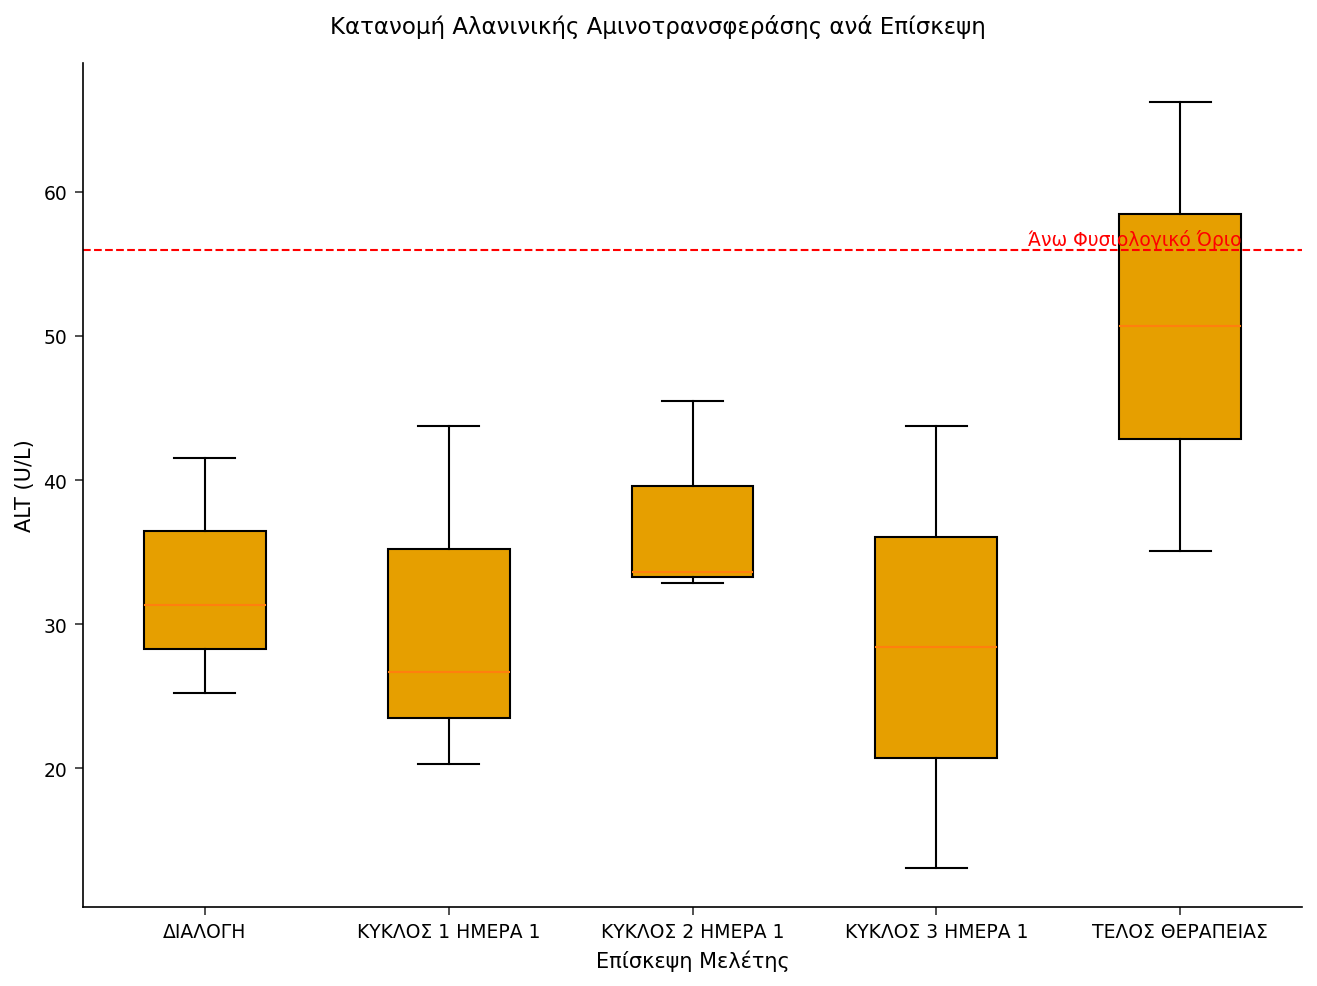

In [5]:
/* --------------------------------------------------------
   Διάγραμμα πλαισίου των τιμών ALT ανά επίσκεψη
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.lab_import;
    ΟΠΟΥ lbtestcd = 'ALT';
    VBOX lbstresn / category=visit;
    REFLINE 56 / AXIS=y LINEATTRS=(pattern=dash color=red)
        label="Άνω Φυσιολογικό Όριο";
    XAXIS label="Επίσκεψη Μελέτης";
    YAXIS label="ALT (U/L)";
    TITLE "Κατανομή Αλανινικής Αμινοτρανσφεράσης ανά Επίσκεψη";
ΕΚΤΕΛΕΣΗ;

In [6]:
/* --------------------------------------------------------
   Ανάλυση εύρους αναφοράς με PROC MEANS και ODS OUTPUT
   Στρωματοποίηση κατά αναλύτη και επίσκεψη για ανασκόπηση
   από τον ιατρικό επόπτη
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.lab_import n mean std MIN MAX;
    ΚΛΑΣΗ lbtestcd visit;
    ΜΕΤΑΒΛΗΤΗ lbstresn;
    ΕΤΙΚΕΤΑ lbtestcd='Κωδικός Εξέτασης' visit='Επίσκεψη' lbstresn='Αποτέλεσμα (Τυπικές Μονάδες)';
    ΕΞΟΔΟΣ out=work.lab_range_summary
        n=n_obs mean=mean_value std=std_value
        MIN=min_value MAX=max_value;
ΕΚΤΕΛΕΣΗ;

                                                  The MEANS Procedure

                   Analysis Variable : lbstresn Αποτέλεσμα (Τυπικές Μονάδες)

        Κωδικός Εξέτασης                 Επίσκεψη                               N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------------------------------------------------------------
        ALB                              ΔΙΑΛΟΓΗ                                    3      4.1666667      0.8533073      3.3600000      5.0600000
        ALB                              ΚΥΚΛΟΣ 1 ΗΜΕΡΑ 1                           3      4.2666667      0.5577036      3.6800000      4.7900000
        ALB                              ΚΥΚΛΟΣ 2 ΗΜΕΡΑ 1                           2      4.0450000      0.0636396      4.0000000      4.0900000
        ALB                              ΚΥΚΛΟΣ 3 ΗΜΕΡΑ 1                           2      4.0500000      0.4101219      


NOTE: PROC MEANS
NOTE: Output dataset work.lab_range_summary has 54 observations and 9 variables.
NOTE: PROC MEANS statement used.


                                                   The FREQ Procedure

Table of Κωδικός Εξέτασης by Σημαία Εκτός Εύρους

Κωδικός Εξέτασης                |                 ΥΨΗΛΟ |           ΦΥΣΙΟΛΟΓΙΚΟ |                ΧΑΜΗΛΟ |                  Total
--------------------------------+-----------------------+-----------------------+-----------------------+-----------------------
ALB                             |                     0 |                    11 |                     1 |                     12
--------------------------------+-----------------------+-----------------------+-----------------------+-----------------------
ALT                             |                     1 |                    12 |                     0 |                     13
--------------------------------+-----------------------+-----------------------+-----------------------+-----------------------
AST                             |                     0 |                    12 |                     1 |


NOTE: DATA work.lab_flagged


NOTE: Read 100 rows from work.lab_import.
NOTE: Wrote work.lab_flagged (100 rows, 16 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_lbtestcd_abnormal_flag.spec.json
NOTE: PROC FREQ statement used.


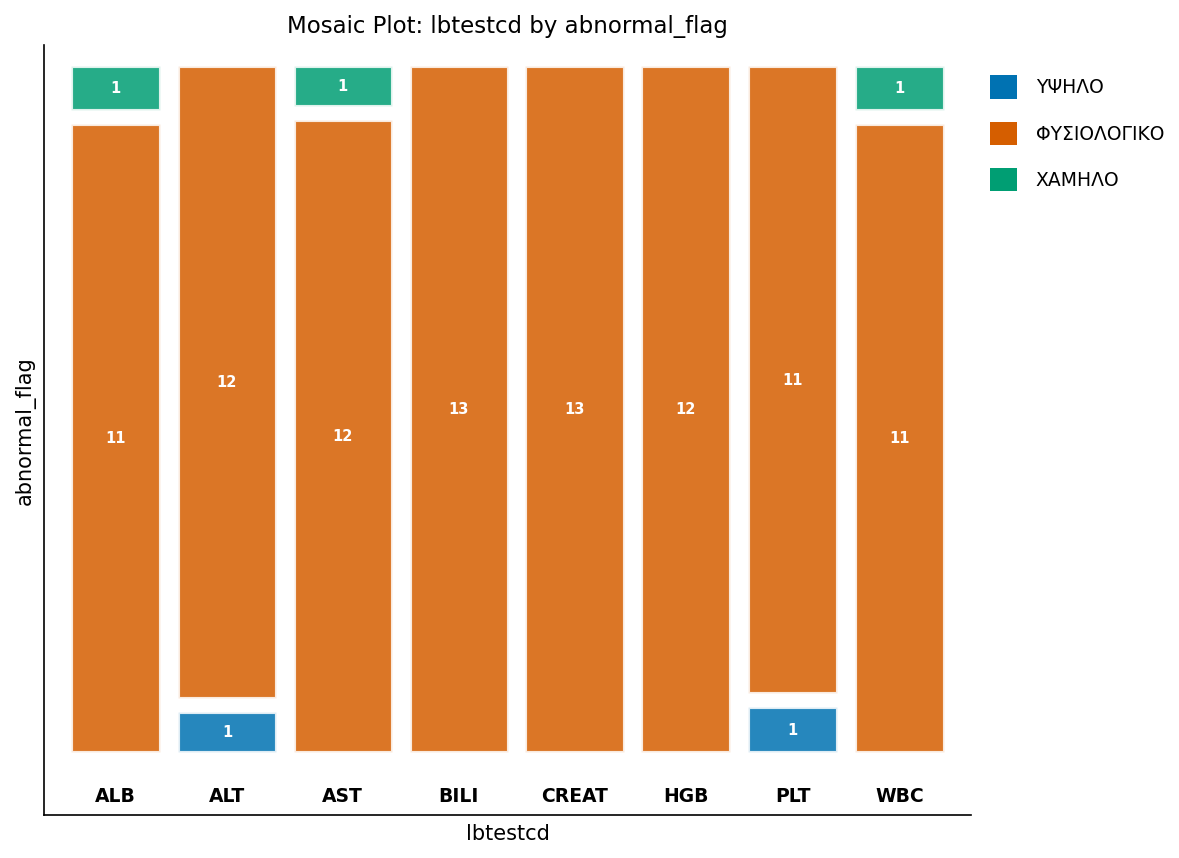

In [7]:
/* --------------------------------------------------------
   Σήμανση αποτελεσμάτων εκτός εύρους αναφοράς
   -------------------------------------------------------- */
ΔΕΔΟΜΕΝΑ work.lab_flagged;
    ΟΡΙΣΜΟΣ work.lab_import;
    LENGTH abnormal_flag $24;
    low_ref = input(lbornrlo, best.);
    high_ref = input(lbornrhi, best.);
    ΕΑΝ lbstresn < low_ref ΤΟΤΕ abnormal_flag = "ΧΑΜΗΛΟ";
    ΑΛΛΙΩΣ ΕΑΝ lbstresn > high_ref ΤΟΤΕ abnormal_flag = "ΥΨΗΛΟ";
    ΑΛΛΙΩΣ abnormal_flag = "ΦΥΣΙΟΛΟΓΙΚΟ";
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΣΥΧΝΟΤΗΤΕΣ ΔΕΔΟΜΕΝΑ=work.lab_flagged;
    TABLES lbtestcd * abnormal_flag / nocum nopercent;
    ΕΤΙΚΕΤΑ lbtestcd='Κωδικός Εξέτασης' abnormal_flag='Σημαία Εκτός Εύρους';
ΕΚΤΕΛΕΣΗ;

---

### Ερμηνεία

Η PROC IMPORT εισήγαγε τις κεντρικές εργαστηριακές εγγραφές από το απόσπασμα CSV, και το GUESSINGROWS=MAX επέτρεψε στον αναγνώστη να σαρώσει κάθε γραμμή πριν καθοριστούν οι τύποι των στηλών, έτσι ώστε η LBSTRESN να συναχθεί ως αριθμητική αντί να υποβιβαστεί σε χαρακτήρα λόγω μιας πρώιμης αραιής τιμής. Η PROC CONTENTS επιβεβαιώνει 13 μεταβλητές (5 αριθμητικές, 8 χαρακτήρων), που ταιριάζουν με την αναμενόμενη δομή εργαστηριακών δεδομένων.

**Σημείωση αναντιστοιχίας:** αυτό το build της Jenner εκτελείται σε λειτουργία χωρίς άδεια ("Unlicensed mode"), η οποία περιορίζει την ανάγνωση/εγγραφή σε 100 παρατηρήσεις αντί για τις πλήρεις 5.000 του συνθετικού συνόλου δεδομένων· ο ίδιος περιορισμός αναπαράγεται ταυτόσημα στο αμετάφραστο αγγλικό notebook-πηγή όταν εκτελεστεί στο ίδιο περιβάλλον, άρα πρόκειται για περιορισμό του engine/build και όχι για σφάλμα του εντοπισμού. Τα στατιστικά παρακάτω αντικατοπτρίζουν το πραγματικό δείγμα των 100 γραμμών που παρήχθη κατά την εκτέλεση, όχι τον αφηγηματικό ισχυρισμό των 5.000 του πηγαίου κειμένου.

Η ανάλυση εύρους αναφοράς δίνει έναν συνολικό μέσο όρο ALT 35,3 U/L (SD 13,4) και μέσο όρο AST 22,2 U/L (SD 9,7), και οι δύο εντός φυσιολογικών ορίων· το διάγραμμα πλαισίου δείχνει κατανομές ALT συγκρίσιμες σε όλες τις πέντε επισκέψεις, με μόνο μία από τις 13 μετρήσεις ALT να ξεπερνά το άνω φυσιολογικό όριο των 56 U/L. Σε αυτό το δείγμα των 100 αποτελεσμάτων, 5 (5,0%) βρίσκονται εκτός του εύρους αναφοράς τους. Επειδή οι συνθετικές τιμές προκύπτουν ως συμμετρική διακύμανση γύρω από το κεντρικό σημείο αναφοράς κάθε αναλύτη, οι σημαίες εκτός εύρους εμφανίζονται στα ALB, ALT, AST, PLT και WBC (7,7%–8,3% έκαστο), ενώ τα BILI, CREAT και HGB δεν εμφανίζουν καμία τιμή εκτός εύρους σε αυτό το μικρότερο δείγμα — αναμενόμενη διακύμανση δειγματοληψίας στις 100 αντί για 5.000 γραμμές, όχι σχεδιασμένη τάση θεραπείας. Αυτά τα συνοπτικά στατιστικά στοιχεία ανά αναλύτη και επίσκεψη είναι το τεκμήριο που θα εξέταζε ένας ιατρικός επόπτης για εργαστηριακά σήματα μόλις τα πραγματικά δεδομένα της μελέτης αντικαταστήσουν το παραγόμενο απόσπασμα.

---

In [8]:
/* --------------------------------------------------------
   Εξαγωγή της συνοπτικής αναφοράς εύρους για τον ιατρικό επόπτη
   -------------------------------------------------------- */
ΔΙΑΔΙΚΑΣΙΑ EXPORT ΔΕΔΟΜΕΝΑ=work.lab_range_summary
    OUTFILE='lab_reference_range_summary.csv'
    DBMS=csv REPLACE;
ΕΚΤΕΛΕΣΗ;


NOTE: PROC EXPORT data=work.lab_range_summary outfile=lab_reference_range_summary.csv

NOTE: Exported 54 rows to lab_reference_range_summary.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Εμπιστευτικό
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Με την υποστήριξη του <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>